Number of clusters: 2
Number of noise points: 8


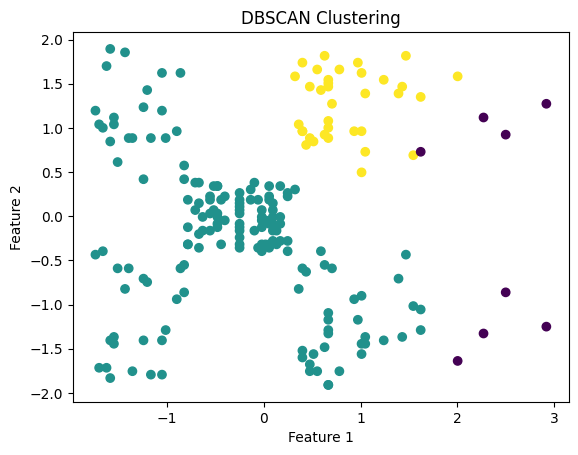

Davies-Bouldin Index: 0.8285103931757107
Calinski-Harabasz Score: 60.838816010569076

--- Performance Metrics ---
Silhouette Score: 0.35044619989666004
Davies-Bouldin Index: 0.8285103931757107
Calinski-Harabasz Score: 60.838816010569076


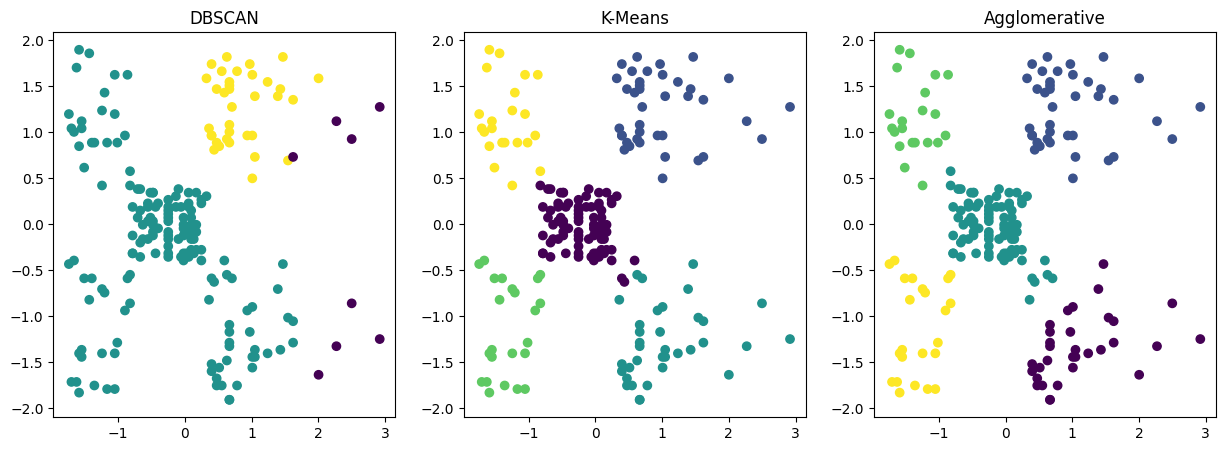


--- DBSCAN ---
Silhouette Score: 0.35044619989666004
Davies-Bouldin Index: 0.8285103931757107
Calinski-Harabasz Score: 60.838816010569076

--- K-Means ---
Silhouette Score: 0.5546571631111091
Davies-Bouldin Index: 0.5722356162263352
Calinski-Harabasz Score: 248.64932001536357

--- Agglomerative ---
Silhouette Score: 0.5538089226688662
Davies-Bouldin Index: 0.5778621190740154
Calinski-Harabasz Score: 244.41032586596822


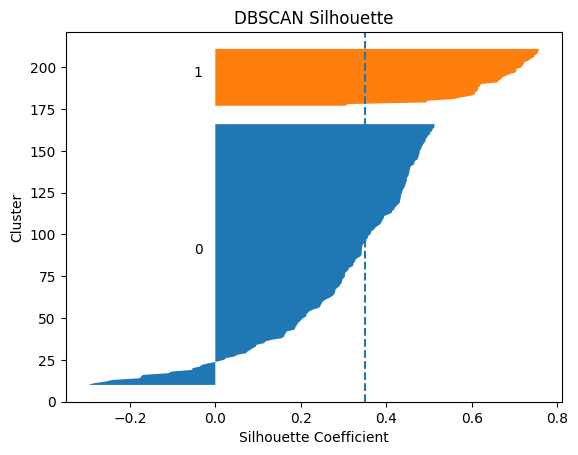

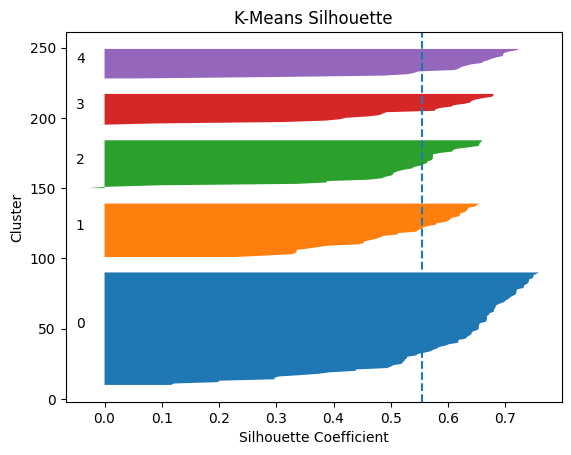

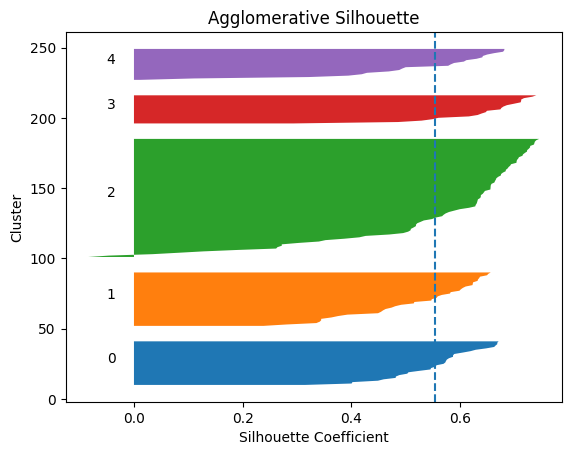

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_samples


df = pd.read_csv('/content/sample_data/Mall_Customers.csv')
X = df.iloc[:, [3, 4]].values  # Example features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Key parameters
labels = dbscan.fit_predict(X_scaled)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

if n_clusters > 1:
    db_index = metrics.davies_bouldin_score(X_scaled, labels)
    print("Davies-Bouldin Index:", db_index)
    ch_score = metrics.calinski_harabasz_score(X_scaled, labels)
    print("Calinski-Harabasz Score:", ch_score)
    print("\n--- Performance Metrics ---")
    print("Silhouette Score:", metrics.silhouette_score(X_scaled, labels))
    print("Davies-Bouldin Index:", db_index) # Using the already computed db_index
    print("Calinski-Harabasz Score:", ch_score) # Using the already computed ch_score
else:
    print("Not enough clusters for evaluation.")

# These lines require 'true_labels' which is not defined in this context.
# They are typically used when you have ground truth labels for your data.
# print("ARI:", adjusted_rand_score(true_labels, labels))
# print("NMI:", normalized_mutual_info_score(true_labels, labels))
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans_labels = kmeans.fit_predict(X_scaled)
# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=5)
agg_labels = agg.fit_predict(X_scaled)
plt.figure(figsize=(15,5))

# DBSCAN
plt.subplot(1,3,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.title("DBSCAN")

# K-Means
plt.subplot(1,3,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("K-Means")

# Hierarchical
plt.subplot(1,3,3)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=agg_labels)
plt.title("Agglomerative")

plt.show()
def evaluate_model(name, X, labels):
    if len(set(labels)) > 1:
        print(f"\n--- {name} ---")
        print("Silhouette Score:", metrics.silhouette_score(X, labels))
        print("Davies-Bouldin Index:", metrics.davies_bouldin_score(X, labels))
        print("Calinski-Harabasz Score:", metrics.calinski_harabasz_score(X, labels))
    else:
        print(f"{name}: Not enough clusters")

# Evaluate all models
evaluate_model("DBSCAN", X_scaled, labels)
evaluate_model("K-Means", X_scaled, kmeans_labels)
evaluate_model("Agglomerative", X_scaled, agg_labels)
def plot_silhouette(X, labels, title):
    if len(set(labels)) <= 1:
        print(f"{title}: Cannot plot silhouette")
        return

    sample_vals = silhouette_samples(X, labels)
    y_lower = 10

    plt.figure()

    for i in set(labels):
        if i == -1:
            continue

        values = sample_vals[labels == i]
        values.sort()
        size = values.shape[0]
        y_upper = y_lower + size

        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, values)
        plt.text(-0.05, y_lower + 0.5 * size, str(i))

        y_lower = y_upper + 10

    plt.axvline(x=metrics.silhouette_score(X, labels), linestyle="--")
    plt.title(title)
    plt.xlabel("Silhouette Coefficient")
    plt.ylabel("Cluster")
    plt.show()
plot_silhouette(X_scaled, labels, "DBSCAN Silhouette")
plot_silhouette(X_scaled, kmeans_labels, "K-Means Silhouette")
plot_silhouette(X_scaled, agg_labels, "Agglomerative Silhouette")